# Feature Evaluation — ETFs

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Evaluate individual feature predictive power via Information Coefficient (IC)
- Apply HAC adjustment for overlapping-return autocorrelation
- Control false discovery rate with Benjamini-Hochberg correction
- Assess feature redundancy and family-level signal concentration
- Produce a triage ledger for downstream model selection

**Book Reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation)
and Section 7.4 (Search accounting and multiple testing). Chapter 8.6 is the
secondary reference for search control.

**Prerequisites**: `03_financial_features.py` and `04_model_based_features.py` must
have run (produce `features/financial.parquet` and `features/model_based.parquet`).

In [1]:
"""Feature Evaluation - ETFs case study."""

import re
import warnings
from datetime import date

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots
from scipy.stats import spearmanr

import utils.style as style
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir

# Register the ML4T Plotly template (colorway, fonts, gridlines) as the default
# and expose the book palette so every figure sources color from utils.style.
style.apply_ml4t_style()
COLORS = style.COLORS
GRAY_FILLS = style.GRAY_FILLS

In [2]:
# Production defaults
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "etfs"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

# ETFs config. Every threshold the screens, the triage rule and the prose refer to
# is bound here. A threshold retyped into a markdown table is a second source of
# truth for a decision the code has already made.
SETUP = load_setup_config(CASE_STUDY_ID)
eval_config = SETUP["evaluation"]

# The label and its horizon come from setup.yaml. The HAC bandwidth is the label
# horizon: it is the overlap the daily-sampled forward return induces, so typing it
# separately would let the correction and the label drift apart.
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
HAC_MAXLAGS = int(re.match(r"^(\d+)", LABEL_BUFFER).group(1))

MIN_PERIODS = 10  # symbols a date needs before its IC enters the series
IC_THRESHOLD = 0.01  # |IC| the exploration arm requires, at a monthly horizon
N_QUANTILES = 5
MIN_COVERAGE = 0.70  # non-null share the correctness gate requires
MAX_STALENESS = 0.50  # unchanged-from-prior-date share the correctness gate allows
FDR_ALPHA = 0.05  # Benjamini-Hochberg level
NAIVE_T = 1.96  # two-sided normal critical value, for the naive-versus-HAC comparison
MIN_SIGN_CONSISTENCY = 0.60  # fold-sign agreement the exploration arm requires
REDUNDANCY_CUT = 0.7  # |rho| above which two features are one piece of evidence

## 0. Load Artifacts & Build Evaluation Panel

We load the pre-computed feature matrices and labels, then join into a single
evaluation panel. Temporal features include both date-level (HMM regime, FFD)
and per-symbol (GARCH) features, so we join on `[date, symbol]`.

The panel is then **sealed to the training+validation window**: because the
triage here promotes features for downstream modeling, the holdout must not
inform feature evaluation. We purge on the 21-day label endpoint, so no
pre-holdout date whose forward label reaches into the holdout survives.

**The fold contract for the Ch9 features.** `model_based.parquet` carries one row
per `(timestamp, symbol, fold)`, and every temporal family in it - the HMM regime
probabilities, the fractionally differenced series and the GARCH conditional
volatility - is fitted on its fold's training window and then written over the
whole fold window (`04_model_based_features.py:20`). A training-date value is
therefore in-sample: the parameters behind it came from a window that extends past
that date. `04` also writes one extra fold, numbered past the last CV fold, whose
training window is everything before `holdout_start`; that one exists to produce
holdout features and has no validation window on this side of the seal.

So the fold column is resolved rather than dropped: a temporal feature is read
only inside the validation window of the fold that produced it, and the extra
holdout fold is dropped. **The evaluation frame is then the union of those
validation windows**, so the Ch8 features are screened on the same rows as the
Ch9 ones. Screening them on the full span instead would compare an IC measured
over eighteen years against one measured over eight, and would leave every
temporal feature failing the coverage gate for a property of its design rather
than a defect.

In [4]:
# Load features (normalize date column type to pl.Date for consistent joins)
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet").with_columns(
    pl.col("timestamp").cast(pl.Date)
)
temporal_artifact = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet").with_columns(
    pl.col("timestamp").cast(pl.Date)
)

# Load primary label
label_df = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet").with_columns(
    pl.col("timestamp").cast(pl.Date)
)
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol")][0]

print(f"Features: {features.shape}")
print(f"Temporal: {temporal_artifact.shape}")
print(f"Labels: {label_df.shape}, column: {label_col}")

Features: (396186, 59)
Temporal: (2567981, 17)
Labels: (468562, 3), column: fwd_ret_21d


In [5]:
# Identify feature columns by source
JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

financial_cols = [c for c in features.columns if c not in JOIN_COLS]
temporal_cols = [c for c in temporal_artifact.columns if c not in (*JOIN_COLS, "fold")]

### The walk-forward folds

`generate_cv_splits` derives the folds from the label frame. It is the same call
`04_model_based_features` makes and the one `load_modeling_dataset` makes in
Chapter 11, so a fold id denotes the same window everywhere it appears.

In [6]:
splits = generate_cv_splits(
    label_df.select(DATE_COL).unique().sort(DATE_COL),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
)


def _as_date(value) -> date:
    return pd.Timestamp(value).date()


for split in splits:
    print(
        f"  Fold {split['fold']}: train {_as_date(split['train_start'])} → "
        f"{_as_date(split['train_end'])}, validation {_as_date(split['val_start'])} → "
        f"{_as_date(split['val_end'])}"
    )

  Fold 0: train 2013-01-17 → 2022-11-28, validation 2022-12-29 → 2023-11-29
  Fold 1: train 2012-01-17 → 2021-11-26, validation 2021-12-29 → 2022-12-28
  Fold 2: train 2011-01-14 → 2020-11-25, validation 2020-12-29 → 2021-12-28
  Fold 3: train 2010-01-15 → 2019-11-26, validation 2019-12-30 → 2020-12-28
  Fold 4: train 2009-01-15 → 2018-11-26, validation 2018-12-28 → 2019-12-27
  Fold 5: train 2008-01-16 → 2017-11-24, validation 2017-12-27 → 2018-12-27
  Fold 6: train 2007-01-17 → 2016-11-23, validation 2016-12-27 → 2017-12-26
  Fold 7: train 2006-01-13 → 2015-11-24, validation 2015-12-28 → 2016-12-23


In [7]:
# A fitted value is out of sample only inside its own fold's validation window, so
# keeping it there and dropping the holdout fold leaves one value per date and symbol.
val_windows = {int(s["fold"]): (_as_date(s["val_start"]), _as_date(s["val_end"])) for s in splits}
IN_VALIDATION = pl.any_horizontal(
    [(pl.col(DATE_COL) >= start) & (pl.col(DATE_COL) <= end) for start, end in val_windows.values()]
)
temporal = (
    temporal_artifact.filter(pl.col("fold").is_in(list(val_windows)))
    .filter(
        pl.col("fold").replace_strict({f: s for f, (s, _) in val_windows.items()}, default=None)
        <= pl.col(DATE_COL)
    )
    .filter(
        pl.col(DATE_COL)
        <= pl.col("fold").replace_strict({f: e for f, (_, e) in val_windows.items()}, default=None)
    )
    .drop("fold")
)
assert temporal.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "validation windows overlap; a fitted feature would take two values on one date"
)

In [8]:
# Join: features + temporal (on [date, symbol]) + labels
eval_panel = features.join(temporal, on=JOIN_COLS, how="left")
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

# Seal the holdout. Feature evaluation is a development decision — the triage
# ledger below promotes features for downstream modeling — so the sealed holdout
# (setup.yaml `evaluation.holdout_start`) must not inform which features look
# predictive. Purge on the LABEL endpoint, not the signal date: a pre-holdout
# date whose 21-day forward label reaches into the holdout would leak holdout
# prices into the IC ranking, BH-FDR, and triage. The label calendar is dense
# (built from the full price panel before eligibility gating), so the endpoint is
# computed there. Same purge as the 02_labels baseline IC and the 03 selection IC.
holdout_start_dt = date.fromisoformat(eval_config["holdout_start"])
LABEL_HORIZON = HAC_MAXLAGS  # fwd_ret_21d: forward window whose endpoint must clear the holdout
last_signal_date = (
    label_df.select("timestamp")
    .unique()
    .sort("timestamp")
    .with_columns(pl.col("timestamp").shift(-LABEL_HORIZON).alias("_label_end"))
    .filter(pl.col("_label_end") < holdout_start_dt)["timestamp"]
    .max()
)
n_before_seal = len(eval_panel)
eval_panel = eval_panel.filter(pl.col("timestamp") <= last_signal_date).filter(IN_VALIDATION)
assert eval_panel[DATE_COL].max() <= last_signal_date
print(
    f"Holdout sealed and narrowed to the validation windows: {n_before_seal:,} -> "
    f"{len(eval_panel):,} rows (labels end < {eval_config['holdout_start']}; "
    f"last eligible signal date {last_signal_date})"
)

all_feature_cols = financial_cols + temporal_cols

if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"\nEval panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} dates")
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Holdout sealed and narrowed to the validation windows: 394,233 -> 188,218 rows (labels end < 2024-01-01; last eligible signal date 2023-11-29)

Eval panel: 188,218 rows, 99 symbols, 1,995 dates
Features: 57 financial + 14 temporal = 71 total
Label: fwd_ret_21d


## Data Quality Gate

Verify upstream artifacts are free of critical defects (negative prices,
infinities, extreme returns) before any statistical evaluation.

**This gate and the per-feature screens below read different rows on purpose.**
The screens are a selection decision and run on the frame where every candidate
exists. This gate asks whether the artifact is sound, and Ch11 trains on every
fold's training window back to the start of the panel, so a broken value outside
the validation windows reaches the model whether or not this notebook screened it.
It reads the whole pre-holdout span, and the temporal artifact as `04` wrote it,
one row per key and fold. It stops at the seal because its counts are printed and
its `fail_on_critical` decides whether this notebook runs at all.

In [9]:
from utils.data_quality import validate_modeling_inputs

sealed_features = features.filter(pl.col(DATE_COL) <= last_signal_date)
sealed_temporal = temporal_artifact.filter(pl.col(DATE_COL) <= last_signal_date)
sealed_labels = label_df.filter(pl.col(DATE_COL) <= last_signal_date)

validate_modeling_inputs(
    features_df=sealed_features,
    label_df=sealed_labels,
    feature_cols=financial_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=1.0,  # a 21-day ETF return above this is a price-adjustment failure
    fail_on_critical=True,
)
validate_modeling_inputs(
    features_df=sealed_temporal,
    label_df=sealed_labels,
    feature_cols=temporal_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=1.0,
    fail_on_critical=True,
)

Data Quality Gate: ALL CLEAR
Data Quality Gate: ALL CLEAR


{'issues': [], 'n_critical': 0, 'n_warning': 0}

## 1. Correctness Screens

Before evaluating predictive power, we check data quality:
- **Coverage**: fraction of non-null values, against `MIN_COVERAGE`
- **Staleness**: fraction of unchanged values from the prior date, against
  `MAX_STALENESS`

Features that fail either gate are marked STOP in the triage.

In [10]:
coverage = {}
staleness = {}

for feat in all_feature_cols:
    col = eval_panel[feat]
    coverage[feat] = col.drop_nulls().len() / n_rows

    # Staleness: fraction unchanged from prior row within same symbol
    unchanged = (
        eval_panel.sort(JOIN_COLS)
        .select((pl.col(feat) == pl.col(feat).shift(1).over("symbol")).alias("same"))["same"]
        .sum()
    )
    staleness[feat] = float(unchanged) / max(n_rows - n_symbols, 1)

correctness = {
    feat: coverage[feat] >= MIN_COVERAGE and staleness[feat] <= MAX_STALENESS
    for feat in all_feature_cols
}
n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [round(coverage[f], 3) for f, ok in correctness.items() if not ok],
            "staleness": [round(staleness[f], 3) for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 67 PASS, 4 FAIL
shape: (4, 3)
┌──────────────────┬──────────┬───────────┐
│ feature          ┆ coverage ┆ staleness │
│ ---              ┆ ---      ┆ ---       │
│ str              ┆ f64      ┆ f64       │
╞══════════════════╪══════════╪═══════════╡
│ aroon_diff       ┆ 1.0      ┆ 0.589     │
│ pct_positive_63d ┆ 1.0      ┆ 0.512     │
│ regime           ┆ 1.0      ┆ 0.978     │
│ vol_63d_rank     ┆ 1.0      ┆ 0.597     │
└──────────────────┴──────────┴───────────┘


### Effective Sample Size

With daily observations and 21-day forward return labels, consecutive labels
overlap by 20 days. This autocorrelation reduces the effective number of
independent observations:

$$N_{\text{eff}} \approx \frac{N_{\text{dates}}}{h} \times N_{\text{symbols}}$$

where $h = 21$ is the label horizon. HAC standard errors (below) account for
this, but raw row counts overstate statistical power.

In [11]:
n_eff_dates = n_dates // HAC_MAXLAGS
n_eff = n_eff_dates * n_symbols
print(f"Raw panel: {n_rows:,} rows ({n_dates:,} dates × {n_symbols} symbols)")
print(
    f"Effective sample size: ~{n_eff:,} ({n_eff_dates:,} independent date blocks × {n_symbols} symbols)"
)
print(f"Overlap reduction factor: {n_dates / n_eff_dates:.0f}x")

Raw panel: 188,218 rows (1,995 dates × 99 symbols)
Effective sample size: ~9,405 (95 independent date blocks × 99 symbols)
Overlap reduction factor: 21x


## 2. Univariate Association (IC + HAC)

For each feature that passes correctness, we compute:
- **IC time series**: daily cross-sectional Spearman rank correlation with the label
- **HAC-adjusted t-statistics**: Newey-West standard errors with bandwidth = 21
  (matching the 21-day label horizon) to account for overlapping-return autocorrelation

Date-level features (identical across all symbols on a given date) produce zero
cross-sectional IC by construction. We detect and flag these separately.

In [12]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

# Detect date-level features (zero cross-sectional variance)
# Compute std per date for all features at once, then check which have ~zero mean std
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

Date-level features (zero CS variance): ['corr_spy_tlt_63d', 'ffd_eem', 'ffd_efa', 'ffd_gld', 'ffd_hyg', 'ffd_iwm', 'ffd_lqd', 'ffd_qqq', 'ffd_spy', 'ffd_tlt', 'ffd_vnq', 'regime_log_duration', 'regime_prob_stress', 'regime_transition', 'yield_curve_slope', 'yield_curve_zscore']


In [13]:
# Batch IC computation: one pass over dates, all features at once
# This is much faster than calling cross_sectional_ic_series per feature
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

# Group by date and compute Spearman IC for all features per date
dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

# Pre-allocate: dict of feature -> list of (date, ic, n_obs)
ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 1000 == 0:
        print(f"  IC progress: {i + 1}/{n_total} dates")

print(f"  IC progress: {n_total}/{n_total} dates (done)")

  IC progress: 1000/1995 dates


  IC progress: 1995/1995 dates (done)


In [14]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 51 cross-sectional features
Skipped 16 date-level features


### Fold-Level Stability

Whether a feature's IC keeps the same sign across the walk-forward validation
windows, which is what separates a feature that works across market regimes from
one that had a single favorable period. The windows are the folds' own validation
windows, so this column and the fold ids everything else in the pipeline uses
denote the same periods.

The quantity measured is agreement with the feature's *own* full-sample sign, not
agreement with a positive sign. A feature that is negative in every fold is as
stable as one that is positive in every fold, and it is the direction a long-short
book would take; counting positive folds instead scores a reliably negative
predictor at zero and makes it unpromotable by construction.

In [15]:
MIN_FOLD_DATES = 5  # dates a fold must contribute before its mean IC is read


def per_fold_mean_ics(feat: str) -> list[float]:
    """Mean IC inside each fold's validation window, under the screen's own rule."""
    ts = ic_timeseries[feat]
    out = []
    for start, end in val_windows.values():
        window = ts.filter((pl.col(DATE_COL) >= start) & (pl.col(DATE_COL) <= end))
        if len(window) >= MIN_FOLD_DATES:
            out.append(float(window["ic"].mean()))
    return out


fold_stats = {}
for feat in ic_results:
    fold_ics = per_fold_mean_ics(feat)
    if fold_ics:
        pooled_sign = np.sign(ic_results[feat]["mean_ic"])
        agreeing = sum(1 for ic in fold_ics if np.sign(ic) == pooled_sign and pooled_sign != 0)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": agreeing / len(fold_ics),
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= MIN_SIGN_CONSISTENCY)
print(
    f"Fold stability computed for {len(fold_stats)} features; {n_consistent} agree with their "
    f"own sign in >= {MIN_SIGN_CONSISTENCY:.0%} of folds"
)

Fold stability computed for 51 features; 37 agree with their own sign in >= 60% of folds


## 3. Multiple Testing (BH-FDR)

Testing this many features simultaneously at `FDR_ALPHA` expects several false
positives by construction, and how many depends on the size of the searched set -
every feature that cleared the correctness gate and produced an IC series, whose
count is printed below. Without it no p-value here is interpretable. The
Benjamini-Hochberg procedure controls the false discovery rate over that set, and
the **inflation factor** measures how much naive significance overstates it:

$$\text{Inflation} = \frac{N_{\text{naive significant}}}{N_{\text{FDR significant}}}$$

In [16]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": [float(p) for p in fdr_result["adjusted_p_values"]],
        "fdr_sig": [bool(r) for r in fdr_result["rejected"]],
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    }
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

# `p_values` holds the HAC p-value, so the naive tier has to come from the naive
# t-statistic. Reading `p_values` here made "naive" a second name for the HAC test
# and forced the HAC inflation ratio to 1.00x whatever the data did.
n_significant_naive = sum(1 for f in feature_names if abs(ic_results[f]["naive_t_stat"]) > NAIVE_T)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > NAIVE_T)
n_significant_fdr = int(fdr_result["n_rejected"])


def inflation(numerator: int, denominator: int) -> str:
    """The ratio, or the reason there isn't one.

    Substituting 1 for a zero denominator turns "the corrected test rejected
    nothing" into a finite ratio that reads as a measurement. The two are
    different statements and the reader gets the one that is true.
    """
    if denominator == 0:
        return "undefined (the corrected test rejects nothing)"
    return f"{numerator / denominator:.2f}x"


print(f"Features tested: {len(feature_names)}")
print(f"Naive significant (|t| > {NAIVE_T}): {n_significant_naive}")
print(f"HAC significant (|t| > {NAIVE_T}):   {n_significant_hac}")
print(f"FDR significant (q < {FDR_ALPHA}):    {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation(n_significant_naive, n_significant_hac)}")
print(f"Inflation factor (FDR): {inflation(n_significant_naive, n_significant_fdr)}")

Features tested: 51
Naive significant (|t| > 1.96): 38
HAC significant (|t| > 1.96):   12
FDR significant (q < 0.05):    0
Inflation factor (HAC): 3.17x
Inflation factor (FDR): undefined (the corrected test rejects nothing)


### The IC series itself

Every statistic above is a scalar summary of one object: the per-date IC series.
Two failure modes are visible only in the series - an IC that comes from a single
episode and is flat around it, and an IC that changes sign between folds - so it is
drawn before it is reduced. The band is the HAC interval around the full-sample
mean, which allows for the serial dependence the overlapping label induces.

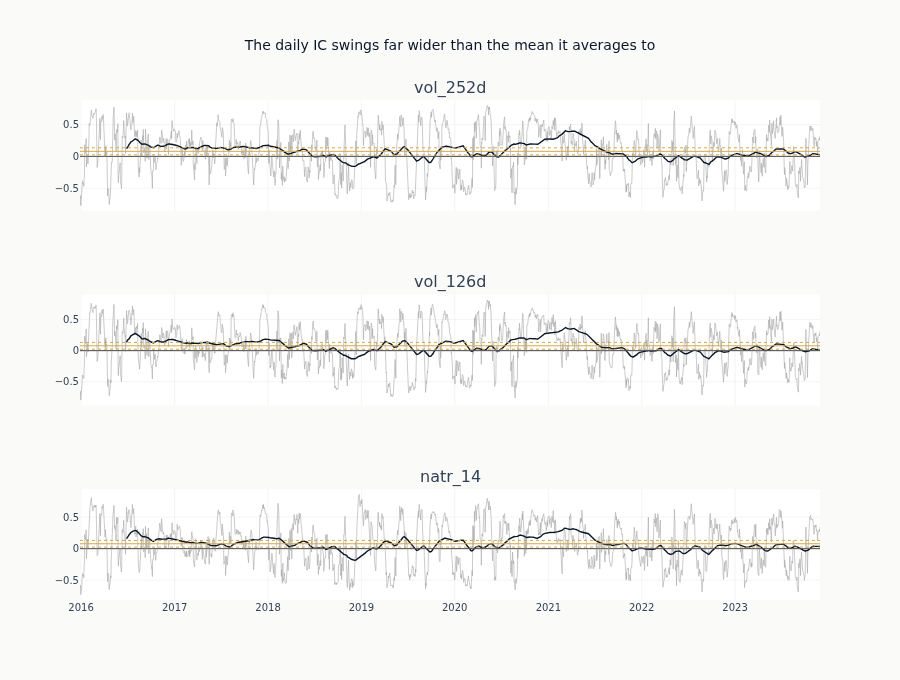

In [17]:
LEADING_FOR_SERIES = 3
ROLLING_DAYS = 126
series_features = eval_summary.head(LEADING_FOR_SERIES)["feature"].to_list()

fig = make_subplots(
    rows=len(series_features), cols=1, shared_xaxes=True, subplot_titles=series_features
)
for row, feat in enumerate(series_features, start=1):
    series = ic_timeseries[feat].sort(DATE_COL)
    bands = compute_ic_uncertainty(series, horizon=HAC_MAXLAGS, ic_col="ic")
    dates = series[DATE_COL].to_list()
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=series["ic"].to_list(),
            mode="lines",
            line=dict(color=GRAY_FILLS["muted"], width=0.6),
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=dates,
            y=series["ic"].rolling_mean(ROLLING_DAYS, min_samples=ROLLING_DAYS).to_list(),
            mode="lines",
            line=dict(color=COLORS["blue"], width=1.4),
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    for value, dash in (
        (bands["mean_ic"], "solid"),
        (bands["ci_hac_lower"], "dot"),
        (bands["ci_hac_upper"], "dot"),
    ):
        fig.add_hline(y=value, line=dict(color=COLORS["amber"], width=1, dash=dash), row=row, col=1)
    fig.add_hline(y=0, line=dict(color=GRAY_FILLS["border"], width=0.8), row=row, col=1)
fig.update_layout(
    template="ml4t",
    height=200 * len(series_features) + 80,
    width=900,
    title_text="The daily IC swings far wider than the mean it averages to",
)
fig.show()

### Feature ranking, with the inference adjustment visible

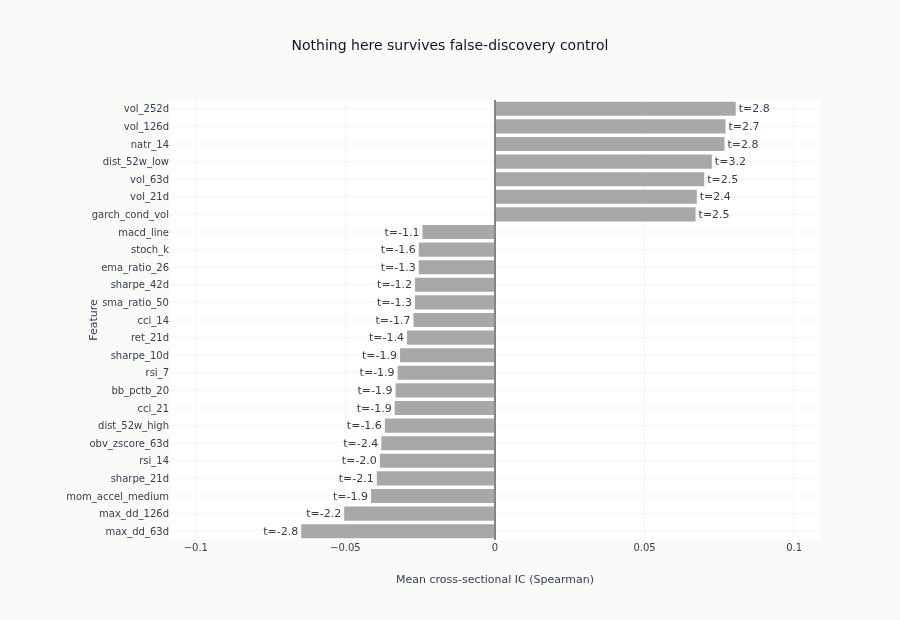

In [18]:
top_n = min(25, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

# One colour convention across every figure in this section: the feature survives
# BH-FDR, or it does not. The earlier version coloured the same category green
# against grey in one panel and green against red in the next, so a reader mapping
# colour to meaning got two answers inside one figure.
SURVIVES, DOES_NOT = COLORS["blue"], GRAY_FILLS["muted"]

fig = go.Figure(
    go.Bar(
        x=top["ic_mean"].to_list(),
        y=top["feature"].to_list(),
        orientation="h",
        marker_color=[SURVIVES if s else DOES_NOT for s in top["fdr_sig"].to_list()],
        text=[f"t={value:.1f}" for value in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    )
)
fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
# Room for the t-statistic label past the end of the longest bar.
ic_span = max(abs(value) for value in top["ic_mean"].to_list()) * 1.35
fig.update_layout(
    template="ml4t",
    height=620,
    width=900,
    title_text="Nothing here survives false-discovery control",
    xaxis_title="Mean cross-sectional IC (Spearman)",
    xaxis_range=[-ic_span, ic_span],
    yaxis_title="Feature",
    margin=dict(l=170),
)
fig.show()

### Fold-level stability

A pooled mean IC hides the difference between a feature that works in every fold
and one that had a single good year. Each feature's per-fold means are drawn with
its median marked, for the same leading features the ranking shows. The dots and
the diamond come from `per_fold_mean_ics`, the function the screen itself reads, so
the median cannot be drawn over a set of folds the chart does not show.

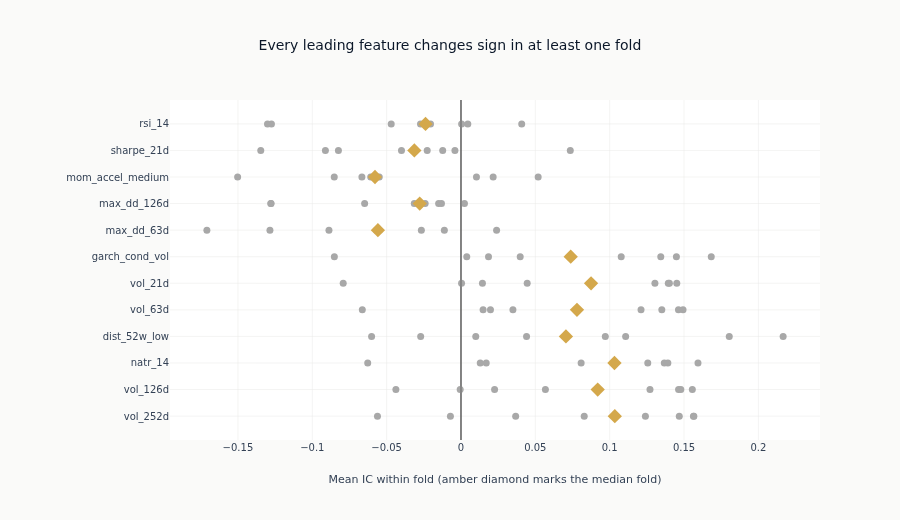

In [19]:
FOLDS_SHOWN = 12
fold_features = [f for f in eval_summary["feature"].to_list() if f in fold_stats][:FOLDS_SHOWN]
fig = go.Figure()
for feat in fold_features:
    per_fold = per_fold_mean_ics(feat)
    fig.add_trace(
        go.Scatter(
            x=per_fold,
            y=[feat] * len(per_fold),
            mode="markers",
            marker=dict(color=GRAY_FILLS["muted"], size=7),
            showlegend=False,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[fold_stats[feat]["median_fold_ic"]],
            y=[feat],
            mode="markers",
            marker=dict(color=COLORS["amber"], size=11, symbol="diamond"),
            showlegend=False,
        )
    )
fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
fig.update_layout(
    template="ml4t",
    height=520,
    width=900,
    title_text="Every leading feature changes sign in at least one fold",
    xaxis_title="Mean IC within fold (amber diamond marks the median fold)",
    margin=dict(l=170),
)
fig.show()

### Naive against HAC inference

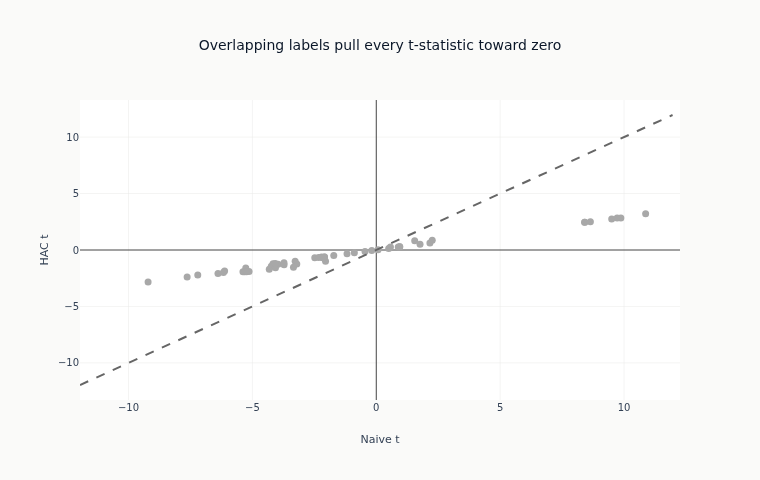

In [20]:
fig = go.Figure(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=[SURVIVES if s else DOES_NOT for s in eval_summary["fdr_sig"].to_list()],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    )
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=GRAY_FILLS["border"]),
        showlegend=False,
    )
)
fig.update_layout(
    template="ml4t",
    height=480,
    width=760,
    title_text="Overlapping labels pull every t-statistic toward zero",
    xaxis_title="Naive t",
    yaxis_title="HAC t",
)
fig.show()

**Interpretation**: points inside the 45-degree line have naive t-statistics that
the HAC correction pulls toward zero, because the overlapping label induces the
autocorrelation a raw test ignores. BH-FDR then penalizes the number of
simultaneous tests on top of that. The markers drawn in blue are the ones that
survive both corrections.

## 4. Shape Diagnostics

Does the label spread monotonically across feature quintiles? A monotone profile
is what a linear model can carry in a single coefficient; a U-shaped one says the
same information is there but not in a form a linear coefficient can hold.

**The quantiles are formed within each date and each date is weighted equally.**
The IC beside them is a within-date rank statistic, so a profile built by pooling
every row and cutting once would be a different object: it would sort a 2016
observation against a 2023 one and let the time-series variation of the feature
stand in for the cross-sectional variation the IC measures. A feature with a
negative IC would then be free to show a rising profile with nothing in the
notebook to reconcile the two.

The mean and the median profile are drawn together. The mean is what a long-short
book earns; the median describes the typical symbol, and a rank statistic like the
IC agrees with the median. Where they disagree the gap is the return tail, not the
shape.

In [21]:
# Show the FDR-significant features first, then fill up to the panel count with the
# next-highest |IC| features, so the diagnostic stays informative when few features
# clear FDR.
fdr_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list()
ranked_shape = eval_summary["feature"].to_list()
top_features_for_shape = (fdr_shape + [f for f in ranked_shape if f not in fdr_shape])[:6]

QUANTILE_LABELS = [f"Q{i + 1}" for i in range(N_QUANTILES)]
MIN_SHAPE_DATES = 20

monotonicity_scores = {}
quantile_spreads = {}

for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, label_col]).drop_nulls()
    # A date needs at least one symbol per bucket before it can be cut into them.
    valid = valid.filter(pl.len().over(DATE_COL) >= N_QUANTILES)
    if valid[DATE_COL].n_unique() < MIN_SHAPE_DATES:
        continue

    binned = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=QUANTILE_LABELS, allow_duplicates=True)
        .over(DATE_COL)
        .alias("quantile")
    )
    # Per date first, then across dates: every date carries the same weight, which is
    # how the IC series beside this is built and how a rebalance experiences it.
    per_date = binned.group_by([DATE_COL, "quantile"]).agg(
        pl.col(label_col).mean().alias("date_mean"),
        pl.col(label_col).median().alias("date_median"),
    )
    profile = (
        per_date.group_by("quantile")
        .agg(
            pl.col("date_mean").mean().alias("mean"),
            pl.col("date_median").mean().alias("median"),
        )
        .sort("quantile")
    )
    means = profile["mean"].to_list()
    quantile_spreads[feat] = {
        "q_means": means,
        "q_medians": profile["median"].to_list(),
        "spread": means[-1] - means[0],
    }

    # monotonicity in the ledger is the Spearman rank correlation between quantile
    # index and mean return, which is the convention the other case studies share.
    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Shape analysis for {len(quantile_spreads)} features")

Shape analysis for 6 features


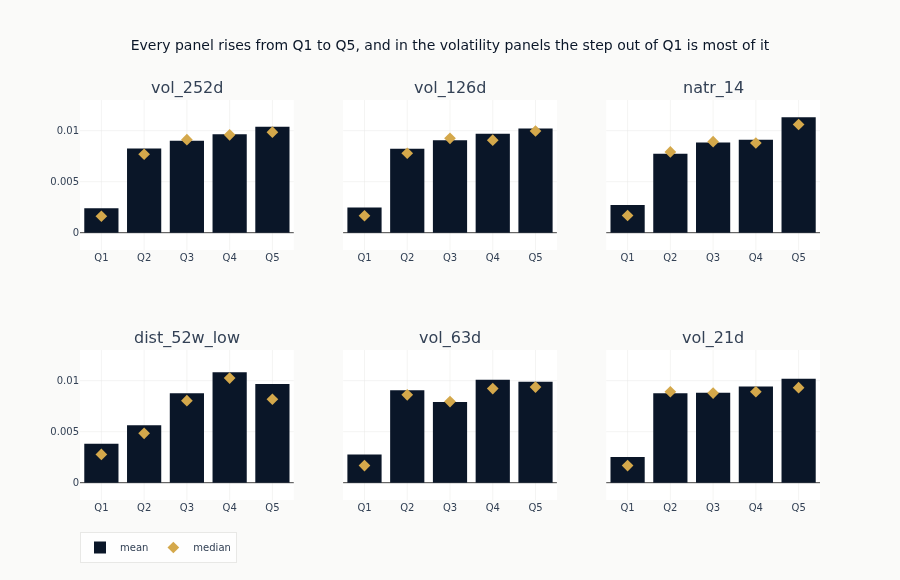

In [22]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show, shared_yaxes=True)
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        fig.add_trace(
            go.Bar(
                x=QUANTILE_LABELS,
                y=quantile_spreads[feat]["q_means"],
                marker_color=COLORS["blue"],
                name="mean",
                legendgroup="mean",
                showlegend=idx == 0,
            ),
            row=r + 1,
            col=c + 1,
        )
        fig.add_trace(
            go.Scatter(
                x=QUANTILE_LABELS,
                y=quantile_spreads[feat]["q_medians"],
                mode="markers",
                marker=dict(color=COLORS["amber"], size=9, symbol="diamond"),
                name="median",
                legendgroup="median",
                showlegend=idx == 0,
            ),
            row=r + 1,
            col=c + 1,
        )
    # One y range across the panels: the point of six panels side by side is that
    # their heights are comparable, which independent auto-scaling destroys. The
    # range is taken from the values and includes zero, rather than being made
    # symmetric, so a panel of same-signed buckets does not spend half its height
    # on empty space.
    profile_values = [
        value
        for feat in feats_to_show
        for key in ("q_means", "q_medians")
        for value in quantile_spreads[feat][key]
    ]
    lo, hi = min(0.0, min(profile_values)), max(0.0, max(profile_values))
    pad = 0.15 * (hi - lo)
    fig.update_yaxes(range=[lo - pad, hi + pad])
    fig.update_layout(
        template="ml4t",
        height=260 * n_rows_fig + 60,
        width=900,
        title_text="Every panel rises from Q1 to Q5, and in the volatility panels the step out of Q1 is most of it",
        legend=dict(orientation="h", y=-0.08),
    )
    fig.show()

**Interpretation**: a monotone profile — Q1 to Q5 consistently rising or falling —
is the shape a Ridge or Lasso fit in Ch11 can carry in a single coefficient.
Where a panel instead turns at one end, the same information is present but a
linear coefficient has to average the turn away, and a tree in Ch12 can split on
it. The median markers separate shape from return tail: where a median sits far
from its bar, that bucket's mean is carried by a few large moves rather than by the
typical symbol.

## 5. Redundancy & Feature Families

We group features into interpretive families and compute family-level IC
aggregates. Feature pairs correlated above `REDUNDANCY_CUT` flag redundancy
that downstream modeling should address via clustering or selection.

In [23]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family based on prefix."""
    FAMILY_MAP = [
        (["sharpe_", "risk_adj"], "risk_adj_momentum"),
        (["skip_recent", "mom_"], "momentum"),
        (["ret_"], "momentum"),
        (["vol_ratio"], "vol_ratio"),
        (["vol_"], "volatility"),
        (["natr", "range_", "max_dd"], "volatility"),
        (["rsi", "macd", "adx", "cci", "stoch", "aroon", "bb_"], "technical"),
        (["sma_", "ema_"], "trend"),
        (["yield_curve", "spy_tlt", "regime", "chop", "hurst"], "regime"),
        (["rank_"], "cross_sectional"),
        (["obv", "turnover", "volume"], "volume"),
        (["pct_positive", "up_ratio"], "consistency"),
        (["dist_"], "distance"),
        (["corr_"], "correlation"),
    ]
    for prefixes, family in FAMILY_MAP:
        if any(p in feature_name.lower() for p in prefixes):
            return family
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

# Override temporal features with specific families
for feat in temporal_cols:
    if "regime" in feat.lower():
        families[feat] = "temporal_regime"
    elif "ffd" in feat.lower():
        families[feat] = "temporal_ffd"
    else:
        families[feat] = "temporal_other"

In [24]:
# Pairwise correlation on sampled dates
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features).to_pandas()
)
corr_matrix = corr_data.corr(method="spearman")

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append((cols[i], cols[j], float(corr_matrix.iloc[i, j])))

print(f"Feature pairs with |corr| > {REDUNDANCY_CUT}: {len(high_corr_pairs)}")

Feature pairs with |corr| > 0.7: 154


In [25]:
# Family-level IC summary
family_ic = {}
fdr_sig_set = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_set,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
else:
    fam_df = pl.DataFrame(
        schema={
            "family": pl.Utf8,
            "n_features": pl.Int64,
            "avg_abs_ic": pl.Float64,
            "avg_ic": pl.Float64,
            "n_fdr_sig": pl.Int64,
        }
    )
print(fam_df)

shape: (10, 5)
┌───────────────────┬────────────┬────────────┬───────────┬───────────┐
│ family            ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---               ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str               ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞═══════════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ volatility        ┆ 7          ┆ 0.069552   ┆ 0.036634  ┆ 0         │
│ temporal_other    ┆ 1          ┆ 0.067047   ┆ 0.067047  ┆ 0         │
│ distance          ┆ 2          ┆ 0.054653   ┆ 0.017838  ┆ 0         │
│ volume            ┆ 1          ┆ 0.038008   ┆ -0.038008 ┆ 0         │
│ technical         ┆ 8          ┆ 0.027139   ┆ -0.027139 ┆ 0         │
│ risk_adj_momentum ┆ 9          ┆ 0.020665   ┆ -0.020665 ┆ 0         │
│ trend             ┆ 3          ┆ 0.019459   ┆ -0.015366 ┆ 0         │
│ regime            ┆ 2          ┆ 0.014776   ┆ -0.004105 ┆ 0         │
│ momentum          ┆ 14         ┆ 0.014431   ┆ -

### Redundancy, as ranked pairs

A full correlation matrix over this many features has unreadable tick labels and
is mostly empty space. What the reader has to decide is which pairs are the same
evidence counted twice, so the strongest pairs are ranked instead, and the count
above `REDUNDANCY_CUT` is printed rather than written into the title.

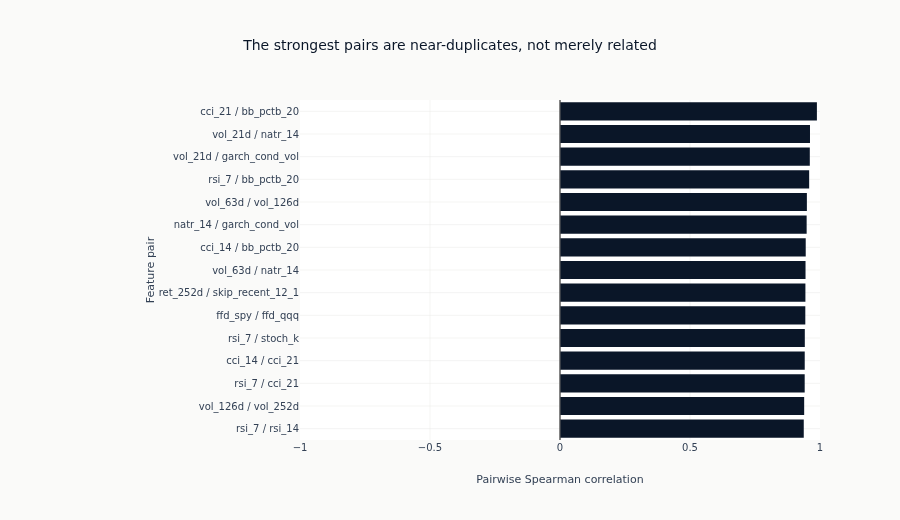

In [26]:
TOP_PAIRS = 15
ranked_pairs = sorted(high_corr_pairs, key=lambda item: -abs(item[2]))[:TOP_PAIRS]
if ranked_pairs:
    fig = go.Figure(
        go.Bar(
            x=[rho for _, _, rho in ranked_pairs][::-1],
            y=[f"{a} / {b}" for a, b, _ in ranked_pairs][::-1],
            orientation="h",
            marker_color=[
                COLORS["blue"] if rho > 0 else COLORS["copper"] for _, _, rho in ranked_pairs
            ][::-1],
            showlegend=False,
        )
    )
    fig.add_vline(x=0, line=dict(color=GRAY_FILLS["border"], width=1))
    fig.update_layout(
        template="ml4t",
        height=520,
        width=900,
        title_text="The strongest pairs are near-duplicates, not merely related",
        xaxis_title="Pairwise Spearman correlation",
        xaxis_range=[-1, 1],
        yaxis_title="Feature pair",
        margin=dict(l=300),
    )
    fig.show()

**Interpretation**: the leading pairs are multi-horizon members of one family -
realized volatility at several windows, returns at several windows, the
fractionally differenced series of ETFs that track overlapping markets. Each pair
is one piece of evidence entered twice, and a ranking that counts them separately
reports a family's breadth as if it were independent corroboration. Ch11 addresses
this by clustering or selecting within families, or by using tree-based models,
which handle correlated inputs without inflating a coefficient.

## 6. Triage & Handoff

Each feature receives a triage decision:

| Decision | Criteria | Arm |
|----------|----------|-----|
| **PROCEED** | BH-FDR significant at `FDR_ALPHA` | confirmation |
| **PROCEED** | sign consistency at least `MIN_SIGN_CONSISTENCY` and abs(IC) at least `IC_THRESHOLD` | exploration |
| **STOP** | correctness FAIL: coverage below `MIN_COVERAGE` or staleness above `MAX_STALENESS` | - |
| **REVISE** | everything else, to be judged in the multivariate context of Ch11 | - |

The rule is a **disjunction**, so PROCEED can exceed the count of FDR-significant
features, and the `note` column records which arm fired. The second arm is an
exploration filter in the sense of Section 7.4, not a significance test: it exists
so false-discovery control does not empty the menu, and a feature promoted through
it has not been confirmed. `IC_THRESHOLD` is a stated judgement about what a
monthly rebalance would need to clear its costs, not a quantity derived from the
data.

Date-level features are triaged as REVISE with a note, since their value
lies in regime-conditional interactions rather than standalone cross-sectional IC.

In [27]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat in date_level_features:
        triage[feat] = ("REVISE", "date_level_feature")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_set
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= MIN_SIGN_CONSISTENCY and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [28]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger saved: {EVAL_DIR / 'triage_ledger.parquet'}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger saved: ~/ml4t/public-cs05-foldfix/case_studies/etfs/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 35  │
│ REVISE   ┆ 32  │
│ STOP     ┆ 4   │
└──────────┴─────┘


In [29]:
# Save IC time series (long format)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series saved: {EVAL_DIR / 'ic_timeseries.parquet'}")

IC time series saved: ~/ml4t/public-cs05-foldfix/case_studies/etfs/evaluation/ic_timeseries.parquet


In [30]:
# Write results JSON
proceed_features = sorted(f for f, (d, _) in triage.items() if d == "PROCEED")
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

sorted_by_ic = sorted(ic_results.items(), key=lambda x: x[1].get("mean_ic") or 0, reverse=True)
best = sorted_by_ic[0] if sorted_by_ic else ("n/a", {})
worst = sorted_by_ic[-1] if sorted_by_ic else ("n/a", {})

In [31]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in proceed_features:
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")


TRIAGE SUMMARY: etfs
  PROCEED: 35 features
  REVISE:  32 features
  STOP:    4 features

PROMOTED (PROCEED) features:
  bb_pctb_20                                IC=-0.0332  t=-1.93  [technical]
  cci_14                                    IC=-0.0272  t=-1.70  [technical]
  cci_21                                    IC=-0.0335  t=-1.94  [technical]
  chop_14                                   IC=+0.0107  t=0.86  [regime]
  dist_52w_high                             IC=-0.0368  t=-1.59  [distance]
  dist_52w_low                              IC=+0.0725  t=3.21  [distance]
  ema_ratio_26                              IC=-0.0255  t=-1.31  [trend]
  garch_cond_vol                            IC=+0.0670  t=2.46  [temporal_other]
  macd_line                                 IC=-0.0242  t=-1.13  [technical]
  max_dd_126d                               IC=-0.0504  t=-2.21  [volatility]
  max_dd_63d                                IC=-0.0648  t=-2.84  [volatility]
  mom_accel_medium                    

**What the triage decided, and on what.** The counts printed above are the whole
output of this notebook: a per-feature decision, with the `note` column recording
which arm promoted it, and **no feature on this panel survives BH-FDR, so every
promotion is an exploration promotion.** The confirmation arm never fires and the
`note` column reads `stable_and_above_threshold` for the whole PROCEED set.

That is a property of the data rather than a fault in the screen. The effective
sample printed above is what a 21-day label leaves of a daily IC series, and
false-discovery control over this many candidates rejects nothing at that sample
size. What the exploration arm keeps on the table is a set that agrees with its own
sign across folds and clears `IC_THRESHOLD`; none of it has been confirmed, and
Ch11 has to read the `note` column to know that.

This notebook does not pronounce on the case study. A univariate screen is
necessary and not sufficient, and whether any of these features are tradable is
settled by a backtest Sharpe several stages later.

## Key Takeaways

1. **Report the searched set beside the p-value.** The naive, HAC and BH-FDR
   counts printed above are three different answers to "how many features carry
   signal", and the gap between them is the price of having tested every feature
   rather than one. A significance claim without the size of the search that
   produced it cannot be read.

2. **HAC adjustment matters**: overlapping 21-day returns create autocorrelation
   in the IC time series, and the Newey-West bandwidth is bound to the label
   horizon rather than typed, so the correction cannot drift from the label.

3. **Screen on the frame where every candidate exists.** The Ch9 features are
   fitted per fold and are out of sample only inside their own validation window.
   Measured over the whole pre-holdout span their coverage is the share of it the
   folds happen to reach, and the correctness gate reads a design property as a
   broken feature; measured over the union of the windows, they are covered and
   comparable with the Ch8 features beside them.

4. **Date-level features require special handling**: regime and macro features
   have zero cross-sectional IC by construction. Their value emerges through
   conditional interactions in Ch11 modeling, so they are triaged REVISE with a
   note rather than scored against a statistic they cannot have.

5. **Redundancy within families**: momentum and volatility features are highly
   correlated, and the ranked-pairs figure says which pairs are one piece of
   evidence counted twice. Downstream modeling should cluster or select
   representative features from each family.

**Next**: `06_linear.py` (Ch11) trains ridge/lasso baselines on the promoted
features, loading the full modeling dataset via `load_modeling_dataset`.